# Function 2 Analysis - Week 12

**Function description:** Function 2 is a noisy black-box objective over two inputs, where the aim is to maximise the returned score.

**Last evaluated point:** `(0.703898, 0.982373)` returned **approximately 0.6362**, so it did not beat the current best.

**Method change (simple):** We replace Thompson Sampling with a simpler BO model that adds one engineered feature, `dist_to_x1_0_7 = |x1 - 0.7|`, and then selects the next point using Expected Improvement in the focus region.


In [25]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_2")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.850000, 0.250000]])
y_new_point_week_1 = np.array([0.4588155729748088])
X_new_point_week_2 = np.array([[0.535400, 0.505100]])
y_new_point_week_2 = np.array([0.4687657102198476])
X_new_point_week_3 = np.array([[0.700000, 0.525000]])
y_new_point_week_3 = np.array([0.5521137017632074])
X_new_point_week_4 = np.array([[0.272472, 0.939888]])
y_new_point_week_4 = np.array([-0.04847445058575585])
X_new_point_week_5 = np.array([[0.680788, 1.000000]])
y_new_point_week_5 = np.array([0.4711629392317611])
X_new_point_week_6 = np.array([[0.734569, 0.990000]])
y_new_point_week_6 = np.array([0.3100296239758809])
X_new_point_week_7 = np.array([[0.680788, 1.000000]])
y_new_point_week_7 = np.array([0.67032012103923])
X_new_point_week_8 = np.array([[0.690000, 0.900000]])
y_new_point_week_8 = np.array([0.6255292381456191])
X_new_point_week_9 = np.array([[0.692542, 0.990644]])
y_new_point_week_9 = np.array([0.745718066464249])
X_new_point_week_10 = np.array([[0.697966, 0.991186]])
y_new_point_week_10 = np.array([0.6416389773332486])
X_new_point_week_11 = np.array([[0.703898, 0.982373]])
y_new_point_week_11 = np.array([0.6361756142699612])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
    X_new_point_week_10,
    X_new_point_week_11,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
    y_new_point_week_10,
    y_new_point_week_11,
])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


df sorted by y


,x1,x2,y
0,0.692542,0.990644,0.745718
1,0.680788,1.000000,0.670320
2,0.697966,0.991186,0.641639
3,0.703898,0.982373,0.636176
4,0.690000,0.900000,0.625529
5,0.702637,0.926564,0.611205
6,0.700000,0.525000,0.552114
7,0.665800,0.123969,0.538996
8,0.680788,1.000000,0.471163
9,0.535400,0.505100,0.468766


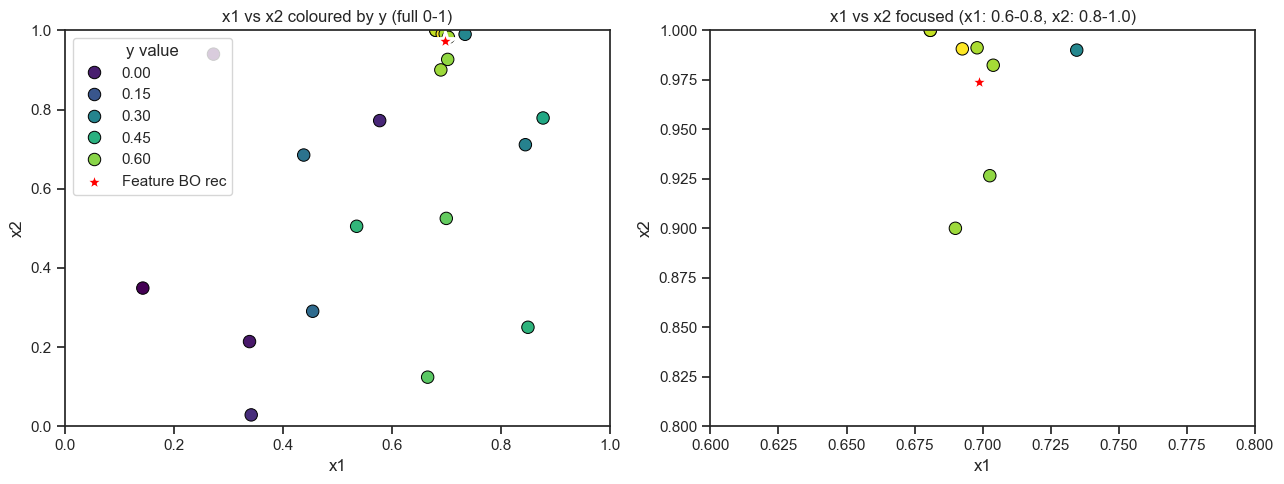

In [26]:
fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(13, 5))

# Full map (existing 0-1 view)
sns.scatterplot(
    data=df,
    x="x1",
    y="x2",
    hue="y",
    palette="viridis",
    s=80,
    edgecolor="black",
    ax=ax_full,
)
ax_full.set_xlim(0, 1)
ax_full.set_ylim(0, 1)
ax_full.set_title("x1 vs x2 coloured by y (full 0-1)")
ax_full.set_xlabel("x1")
ax_full.set_ylabel("x2")

# Overlay feature-BO recommendation on both plots (if computed below)
try:
    ax_full.scatter(
        X_recommend_updated[0, 0],
        X_recommend_updated[0, 1],
        c="red",
        s=200,
        marker="*",
        edgecolor="white",
        linewidths=2,
        label="Feature BO rec",
    )
except NameError:
    pass

# Focused map (requested narrow square)
sns.scatterplot(
    data=df,
    x="x1",
    y="x2",
    hue="y",
    palette="viridis",
    s=80,
    edgecolor="black",
    ax=ax_zoom,
    legend=False,
)
ax_zoom.set_xlim(0.6, 0.8)
ax_zoom.set_ylim(0.8, 1.0)
ax_zoom.set_title("x1 vs x2 focused (x1: 0.6-0.8, x2: 0.8-1.0)")
ax_zoom.set_xlabel("x1")
ax_zoom.set_ylabel("x2")

try:
    ax_zoom.scatter(
        X_recommend_updated[0, 0],
        X_recommend_updated[0, 1],
        c="red",
        s=200,
        marker="*",
        edgecolor="white",
        linewidths=2,
        label="Feature BO rec",
    )
except NameError:
    pass

ax_full.legend(title="y value", loc="best")
plt.tight_layout()
plt.show()


In [27]:
# Simple feature-engineered BO
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from scipy.stats import norm

# Add engineered feature
# dist_to_x1_0_7 is distance to the vertical line x1 = 0.7
df_feat = df.copy()
df_feat["dist_to_x1_0_7"] = np.abs(df_feat["x1"] - 0.7)

X_train = df_feat[["x1", "x2", "dist_to_x1_0_7"]].values
y_train = df_feat["y"].values

best_row_obs = df_feat.loc[df_feat["y"].idxmax()]
best_y = float(best_row_obs["y"])

# Fit a simple noisy GP
kernel = (
    ConstantKernel(1.0, (1e-3, 20.0))
    * Matern(length_scale=[0.12, 0.12, 0.06], length_scale_bounds=(0.01, 0.5), nu=2.5)
    + WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-3, 0.3))
)
gp_bo = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=8, random_state=42)
gp_bo.fit(X_train, y_train)

# Evaluate candidates in focus region
bo_x1_min, bo_x1_max = 0.60, 0.80
bo_x2_min, bo_x2_max = 0.80, 1.00
grid_res = 70

bo_grid_x1 = np.linspace(bo_x1_min, bo_x1_max, grid_res)
bo_grid_x2 = np.linspace(bo_x2_min, bo_x2_max, grid_res)
bo_mesh_2d = np.array(np.meshgrid(bo_grid_x1, bo_grid_x2)).reshape(2, -1).T
bo_dist = np.abs(bo_mesh_2d[:, 0] - 0.7)
bo_mesh_3d = np.column_stack([bo_mesh_2d, bo_dist])

mu_bo, sigma_bo = gp_bo.predict(bo_mesh_3d, return_std=True)
sigma_bo = np.maximum(sigma_bo, 1e-9)

# Expected Improvement (slightly more exploratory)
xi = 0.02
imp = mu_bo - best_y - xi
Z = imp / sigma_bo
ei_bo = imp * norm.cdf(Z) + sigma_bo * norm.pdf(Z)

candidate_df = pd.DataFrame({
    "x1": bo_mesh_2d[:, 0],
    "x2": bo_mesh_2d[:, 1],
    "dist_to_x1_0_7": bo_dist,
    "mu": mu_bo,
    "sigma": sigma_bo,
    "ei": ei_bo,
})

# Small anti-duplicate filter (slightly stronger to encourage exploration)
obs_xy = df_feat[["x1", "x2"]].values
cand_xy = candidate_df[["x1", "x2"]].values
min_dist = np.sqrt(((cand_xy[:, None, :] - obs_xy[None, :, :]) ** 2).sum(axis=2)).min(axis=1)
candidate_df = candidate_df[min_dist >= 0.015].copy()

best_row = candidate_df.loc[candidate_df["ei"].idxmax()]
bo_next_x1, bo_next_x2 = float(best_row["x1"]), float(best_row["x2"])

# Used by plotting cells
X_recommend_updated = np.array([[bo_next_x1, bo_next_x2]])

print(f"Current best observed y: {best_y:.6f}")
print(f"BO RECOMMENDED POINT: ({bo_next_x1:.6f}, {bo_next_x2:.6f})")
print(f"Predicted mean: {best_row['mu']:.6f} | EI: {best_row['ei']:.6f}")
print(f"Distance feature |x1-0.7| at recommendation: {abs(bo_next_x1 - 0.7):.6f}")
print(f"Format for submission: {bo_next_x1:.6f}-{bo_next_x2:.6f}")

Current best observed y: 0.745718
BO RECOMMENDED POINT: (0.698551, 0.968116)
Predicted mean: 0.651415 | EI: 0.003290
Distance feature |x1-0.7| at recommendation: 0.001449
Format for submission: 0.698551-0.968116


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


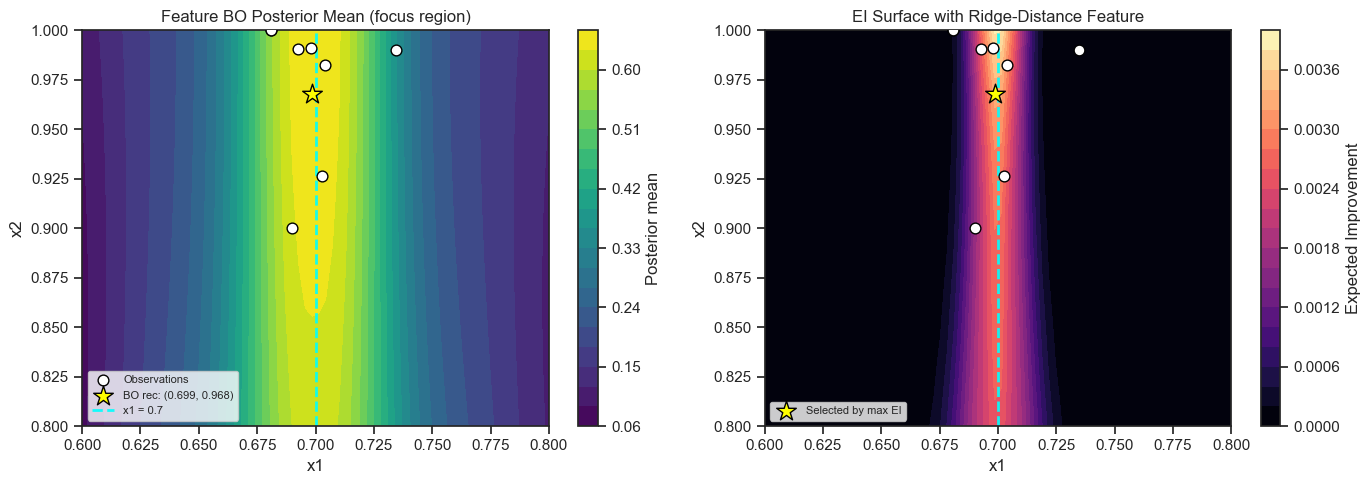


FEATURE-ENGINEERED BO RECOMMENDED POINT: (0.698551, 0.968116)
Format for submission: 0.698551-0.968116


In [28]:
# Visualize feature-engineered BO results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

mu_grid = mu_bo.reshape(grid_res, grid_res)
ei_grid = ei_bo.reshape(grid_res, grid_res)

# Left: posterior mean in focused square
contour1 = ax1.contourf(bo_grid_x1, bo_grid_x2, mu_grid, levels=20, cmap="viridis")
plt.colorbar(contour1, ax=ax1, label="Posterior mean")

# Observations and recommendation
ax1.scatter(df["x1"], df["x2"], c="white", s=60, edgecolor="black", zorder=5, label="Observations")
ax1.scatter(bo_next_x1, bo_next_x2, c="yellow", s=220, marker="*", edgecolor="black", zorder=7,
            label=f"BO rec: ({bo_next_x1:.3f}, {bo_next_x2:.3f})")
ax1.axvline(0.7, color="cyan", linestyle="--", linewidth=2, alpha=0.9, label="x1 = 0.7")

ax1.set_xlim(bo_x1_min, bo_x1_max)
ax1.set_ylim(bo_x2_min, bo_x2_max)
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_title("Feature BO Posterior Mean (focus region)")
ax1.legend(loc="lower left", fontsize=8)

# Right: EI acquisition surface
contour2 = ax2.contourf(bo_grid_x1, bo_grid_x2, ei_grid, levels=20, cmap="magma")
plt.colorbar(contour2, ax=ax2, label="Expected Improvement")

ax2.scatter(df["x1"], df["x2"], c="white", s=60, edgecolor="black", zorder=5)
ax2.scatter(bo_next_x1, bo_next_x2, c="yellow", s=220, marker="*", edgecolor="black", zorder=7,
            label="Selected by max EI")
ax2.axvline(0.7, color="cyan", linestyle="--", linewidth=2, alpha=0.9)

ax2.set_xlim(bo_x1_min, bo_x1_max)
ax2.set_ylim(bo_x2_min, bo_x2_max)
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_title("EI Surface with Ridge-Distance Feature")
ax2.legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"FEATURE-ENGINEERED BO RECOMMENDED POINT: ({bo_next_x1:.6f}, {bo_next_x2:.6f})")
print(f"Format for submission: {bo_next_x1:.6f}-{bo_next_x2:.6f}")
print(f"{'='*60}")

## Final Method Summary

**Current best:** `0.692542-0.990644` (≈0.7457)

**Last evaluated point:** `0.703898-0.982373` returned ≈0.6362, which did not improve the incumbent.

**Why the old approach was removed:**
- The previous Thompson-based setup was too exploitative in this run.
- It repeatedly focused on a very narrow neighborhood and did not produce a better point.
- We therefore removed that path and kept a cleaner BO pipeline.

**New feature and intuition:**
- We add `dist_to_x1_0_7 = |x1 - 0.7|` as a third input to the surrogate model.
- This encodes a structural prior that performance may depend strongly on closeness to the vertical ridge near `x1 = 0.7`.
- Instead of learning ridge proximity only indirectly from noisy `(x1, x2)` observations, the GP receives this signal explicitly.

**What this changes in BO behavior:**
- The model can share information between points that have similar distance-to-ridge, even when `x2` differs.
- This usually gives a smoother and more data-efficient local model in noisy settings.
- We still preserve uncertainty-aware search through Expected Improvement (EI), so the method is not purely exploitative.

**Simple BO pipeline now used:**
1. Build training data with features `(x1, x2, |x1-0.7|)`.
2. Fit a noisy Gaussian Process surrogate.
3. Evaluate candidate points in the focus box (`x1: 0.6-0.8`, `x2: 0.8-1.0`).
4. Compute EI for all candidates.
5. Remove near-duplicate candidates too close to already observed points.
6. Choose the max-EI candidate as the recommendation.

**Proposed next point (submission format):** use the `Format for submission: ...` value printed by the BO cell above.
